In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uri="https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"
tit = pd.read_csv(uri)

In [2]:
tit.sample(10,random_state=15)

,rownames,survived,sex,age,passengerClass
1198,"Shine, Miss. Ellen Natalia",yes,female,NaN,3rd
1207,"Skoog, Master. Karl Thorsten",no,male,10.0,3rd
1116,"Peduzzi, Mr. Joseph",no,male,NaN,3rd
730,"Cor, Mr. Ivan",no,male,27.0,3rd
1214,"Smiljanic, Mr. Mile",no,male,NaN,3rd
1121,"Peter, Master. Michael J",yes,male,NaN,3rd
184,"Lewy, Mr. Ervin G",no,male,NaN,1st
797,"Farrell, Mr. James",no,male,40.5,3rd
336,"Beane, Mr. Edward",yes,male,32.0,2nd
92,"Dick, Mrs. Albert Adrian (Vera",yes,female,17.0,1st


In [3]:
tit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rownames        1309 non-null   str    
 1   survived        1309 non-null   str    
 2   sex             1309 non-null   str    
 3   age             1046 non-null   float64
 4   passengerClass  1309 non-null   str    
dtypes: float64(1), str(4)
memory usage: 95.7 KB


In [4]:
tit.describe()

,age
count,1046.000000
mean,29.881135
std,14.413500
min,0.166700
25%,21.000000
50%,28.000000
75%,39.000000
max,80.000000


In [5]:
tit.passengerClass.unique()

<ArrowStringArray>
['1st', '2nd', '3rd']
Length: 3, dtype: str

In [6]:
tit.sex.unique()

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

In [13]:
m_survived = tit[tit.survived == 'yes'].copy()
m_survived.sample(10,random_state=15)

,rownames,survived,sex,age,passengerClass
785,"Dyker, Mrs. Adolf Fredrik (Anna",yes,female,22.0,3rd
86,"Daly, Mr. Peter Denis",yes,male,51.0,1st
502,"Mellinger, Mrs. (Elizabeth Anne",yes,female,41.0,2nd
872,"Howard, Miss. May Elizabeth",yes,female,NaN,3rd
324,"Abelson, Mrs. Samuel (Hannah Wi",yes,female,28.0,2nd
400,"Drew, Mrs. James Vivian (Lulu T",yes,female,34.0,2nd
233,"Potter, Mrs. Thomas Jr (Lily Al",yes,female,56.0,1st
1017,"Midtsjo, Mr. Karl Albert",yes,male,21.0,3rd
798,"Finoli, Mr. Luigi",yes,male,NaN,3rd
159,"Hippach, Miss. Jean Gertrude",yes,female,16.0,1st


In [11]:
m_died = tit[tit.survived == 'no'].copy()
m_died.sample(10,random_state=15)

,rownames,survived,sex,age,passengerClass
614,"Alexander, Mr. William",no,male,26.0,3rd
221,"Ostby, Mr. Engelhart Cornelius",no,male,65.0,1st
1126,"Petranec, Miss. Matilda",no,female,28.0,3rd
635,"Arnold-Franchi, Mr. Josef",no,male,25.0,3rd
239,"Roebling, Mr. Washington August",no,male,31.0,1st
1301,"Youseff, Mr. Gerious",no,male,45.5,3rd
1306,"Zakarian, Mr. Mapriededer",no,male,26.5,3rd
369,"Chapman, Mrs. John Henry (Sara",no,female,29.0,2nd
1230,"Strom, Miss. Telma Matilda",no,female,2.0,3rd
1273,"Vander Planke, Miss. Augusta Ma",no,female,18.0,3rd


In [7]:
m_female = tit[tit.sex == 'female'].copy()
m_female.sample(5,random_state=15)

,rownames,survived,sex,age,passengerClass
1001,"McCoy, Miss. Agnes",yes,female,NaN,3rd
1028,"Moran, Miss. Bertha",yes,female,NaN,3rd
603,"Abbott, Mrs. Stanton (Rosa Hunt",yes,female,35.0,3rd
291,"Taussig, Mrs. Emil (Tillie Mand",yes,female,39.0,1st
494,"Mallet, Mrs. Albert (Antoinette",yes,female,24.0,2nd


In [8]:
m_male = tit[tit.sex == 'male'].copy()
m_male.sample(5,random_state=15)

,rownames,survived,sex,age,passengerClass
173,"Keeping, Mr. Edwin",no,male,32.5,1st
1168,"Sadowitz, Mr. Harry",no,male,NaN,3rd
1119,"Perkin, Mr. John Henry",no,male,22.0,3rd
796,"Everett, Mr. Thomas James",no,male,40.5,3rd
509,"Morley, Mr. Henry Samuel (Mr H",no,male,39.0,2nd


In [9]:
print(f"Male: {len(m_male)} mean age {m_male['age'].mean():.2f}")
print(f"Female: {len(m_female)} mean age {m_female['age'].mean():.2f}")

Male: 843 mean age 30.59
Female: 466 mean age 28.69


Per i sopravvissuti:
- Età media e numero sopravvissuti per classe
- Età media e numero sopravvissuti per fascia di età

In [14]:
bins = [0, 12, 18, 60, 100]
labels = ['Bambini (0-11)', 'Adolescenti (12-17)', 'Adulti (18-59)', 'Anziani (60+)']
m_survived['age_group'] = pd.cut(m_survived['age'], bins=bins, labels=labels, right=False)


surv_by_class = (m_survived
                 .groupby("passengerClass")["age"]
                 .agg(n_sopravvissuti="count", eta_media="mean")
                 .round(2)
                 .reset_index())
surv_by_class

,passengerClass,n_sopravvissuti,eta_media
0,1st,181,36.83
1,2nd,115,24.86
2,3rd,131,21.55


In [15]:
surv_by_age_group = (m_survived
                     .groupby("age_group")["age"]
                     .agg(n_sopravvissuti="count", eta_media="mean")
                     .round(2)
                     .reset_index())
surv_by_age_group

,age_group,n_sopravvissuti,eta_media
0,Bambini (0-11),51,3.84
1,Adolescenti (12-17),30,15.10
2,Adulti (18-59),334,32.71
3,Anziani (60+),12,64.50


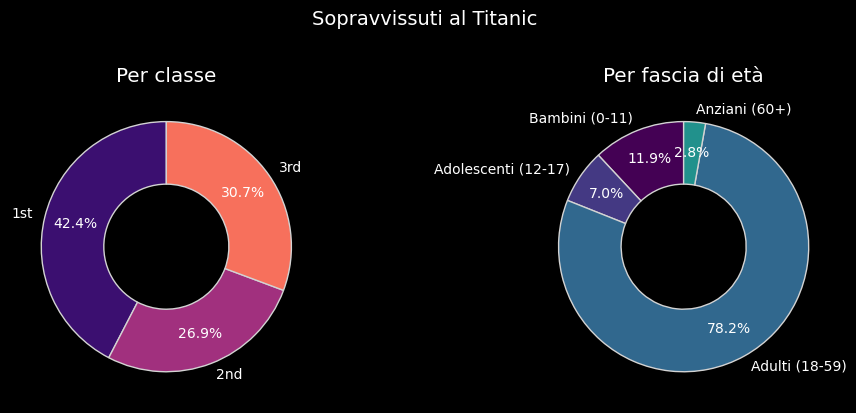

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.style.use(["dark_background", "bmh"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wp = {"width": 0.5, "edgecolor": "lightgrey", "linewidth": 1}

colors_class = cm.magma(np.linspace(0.2, 0.7, len(surv_by_class))) # type: ignore
colors_age = cm.viridis(np.linspace(0, 0.5, len(surv_by_age_group))) # type: ignore

axes[0].pie(
    surv_by_class["n_sopravvissuti"],
    labels=surv_by_class["passengerClass"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=wp,
    pctdistance=0.75,
    colors=colors_class
)
axes[0].set_title("Per classe")

axes[1].pie(
    surv_by_age_group["n_sopravvissuti"],
    labels=surv_by_age_group["age_group"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=wp,
    pctdistance=0.75,
    colors=colors_age
)
axes[1].set_title("Per fascia di età")

fig.suptitle("Sopravvissuti al Titanic", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

## Esercizio

Questo esercizio utilizza il dataset del Titanic per costruire un modello di classificazione che prevede se un passeggero è sopravvissuto.

Passaggi:
1. Separare le feature (X) e il target (y).
2. Gestire i valori mancanti per l'età e codificare le variabili categoriche (`sex`, `passengerClass`).
3. Confrontare due modelli: `DecisionTreeClassifier` e `RandomForestClassifier`.
4. Valutare l'accuratezza su un set di test separato.

Nota: `rownames` è una colonna di identificazione non utile per la predizione e viene eliminata.

In [17]:
print(tit.isnull().sum())

rownames            0
survived            0
sex                 0
age               263
passengerClass      0
dtype: int64


In [35]:
# Import delle librerie necessarie
import pandas as pd 
from sklearn.model_selection import train_test_split  # per dividere il dataset in train e test
from sklearn.compose import ColumnTransformer  # per applicare trasformazioni diverse a colonne diverse
from sklearn.pipeline import Pipeline  # per concatenare preprocessing e modello in un unico flusso
from sklearn.impute import SimpleImputer  # per gestire i valori mancanti
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Aggiunto StandardScaler per la SVM
from sklearn.tree import DecisionTreeClassifier  # modello ad albero decisionale
from sklearn.ensemble import RandomForestClassifier  # ensemble di alberi decisionali
from sklearn.svm import SVC  # Modello Support Vector Classifier (SVM)

# 1. Preparazione dei dati: separazione tra feature (X) e target (y)
X = tit.drop(columns=['survived', 'rownames'])
y = tit['survived']

# 2. Divisione del dataset in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

# 3. Definizione del preprocessamento
num_cols = ['age']
cat_cols = ['sex', 'passengerClass']

# Creiamo una sotto-pipeline per i dati numerici: prima imputa la media, poi standardizza (fondamentale per SVM)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer aggiornato con il num_transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_features', num_transformer, num_cols),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# 4. Creazione delle pipeline per i TRE modelli
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Sottoposizione della SVM (SVC sta per Support Vector Classifier)
pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, class_weight='balanced'))
])

# 5. Addestramento dei modelli
pipeline_dt.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)  # Allenamento SVM

# 6. Valutazione dei modelli
acc_dt = pipeline_dt.score(X_test, y_test)
acc_rf = pipeline_rf.score(X_test, y_test)
acc_svm = pipeline_svm.score(X_test, y_test)  # Punteggio SVM

# 7. Confronto dei risultati
print("--- RISULTATI DEL CONFRONTO ---")
print(f"Accuratezza Decision Tree: {acc_dt:.2%}")
print(f"Accuratezza Random Forest: {acc_rf:.2%}")
print(f"Accuratezza Support Vector Machine: {acc_svm:.2%}")

--- RISULTATI DEL CONFRONTO ---
Accuratezza Decision Tree: 80.92%
Accuratezza Random Forest: 80.41%
Accuratezza Support Vector Machine: 80.41%
